## Stepan-VORONYI-Camp-2026
# Hometask lesson 15: Sentiment Analysis
## Libraries Initialization

In [5]:
import sys
!{sys.executable} -m pip install "numpy<2.0.0" "gensim==4.3.2" --force-reinstall

  Using cached smart_open-7.6.1-py3-none-any.whl.metadata (25 kB)
   ---------------------------------------- 0.0/24.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.0 MB ? eta -:--:--
    --------------------------------------- 0.5/24.0 MB 1.2 MB/s eta 0:00:20
   - -------------------------------------- 0.8/24.0 MB 1.2 MB/s eta 0:00:20
   - -------------------------------------- 1.0/24.0 MB 1.2 MB/s eta 0:00:19
   -- ------------------------------------- 1.3/24.0 MB 1.2 MB/s eta 0:00:19
   -- ------------------------------------- 1.6/24.0 MB 1.2 MB/s eta 0:00:19
   --- ------------------------------------ 1.8/24.0 MB 1.2 MB/s eta 0:00:19
   --- ------------------------------------ 2.1/24.0 MB 1.2 MB/s eta 0:00:18
   --- ------------------------------------ 2.4/24.0 MB 1.2 MB/s eta 0:00:18
   ---- ----------------------------------- 2.6/24.0 MB 1.2 MB/s eta 0:00:18
   ---- -----------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 3.20.2 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import nltk
from nltk.tokenize import word_tokenize
import gensim
from gensim.models import Word2Vec
from transformers import pipeline
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

c:\Users\Stepan\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [8]:
fn_neg = 'rt-polaritydata\\rt-polarity.neg'
fn_pos = 'rt-polaritydata\\rt-polarity.pos'

with open(fn_neg, "r", encoding='utf-8', errors='ignore') as f:
    texts_neg = f.read().splitlines()

with open(fn_pos, "r", encoding='utf-8', errors='ignore') as f:
    texts_pos = f.read().splitlines()

## EDA

In [9]:
print(f"Total Negative Snippets: {len(texts_neg):,}")
print(f"Total Positive Snippets: {len(texts_pos):,}")

print("\nSample Negative Review:")
print(texts_neg[0])
print("\nSample Positive Review:")
print(texts_pos[0])

Total Negative Snippets: 5,331
Total Positive Snippets: 5,331

Sample Negative Review:
simplistic , silly and tedious . 

Sample Positive Review:
the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal . 


## Dataset Preparation

In [10]:
df_neg = pd.DataFrame({'text': texts_neg, 'label': 0})
df_pos = pd.DataFrame({'text': texts_pos, 'label': 1})

df = pd.concat([df_neg, df_pos], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

## Perform stratified split to preserve class balance

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=df['label']
)

print(f"Train Shape: {X_train.shape[0]} | Test Shape: {X_test.shape[0]}")

Train Shape: 8529 | Test Shape: 2133


## Statistical Visualization

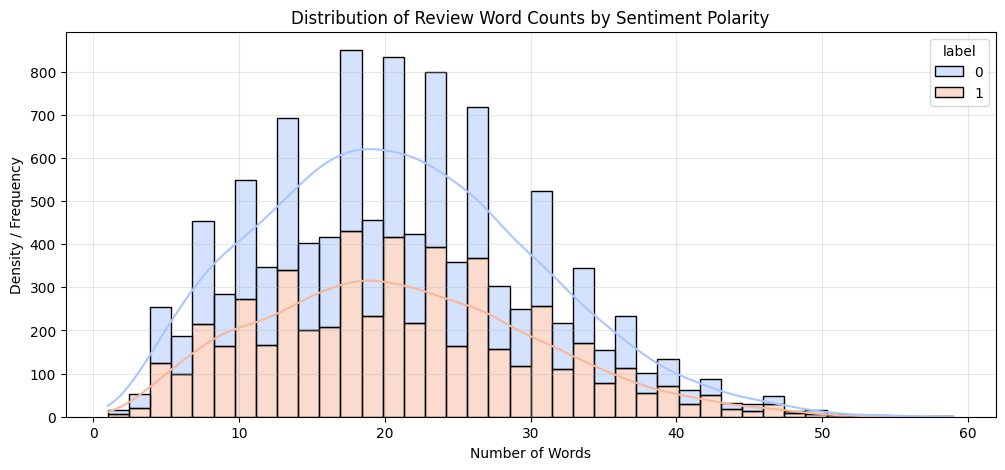

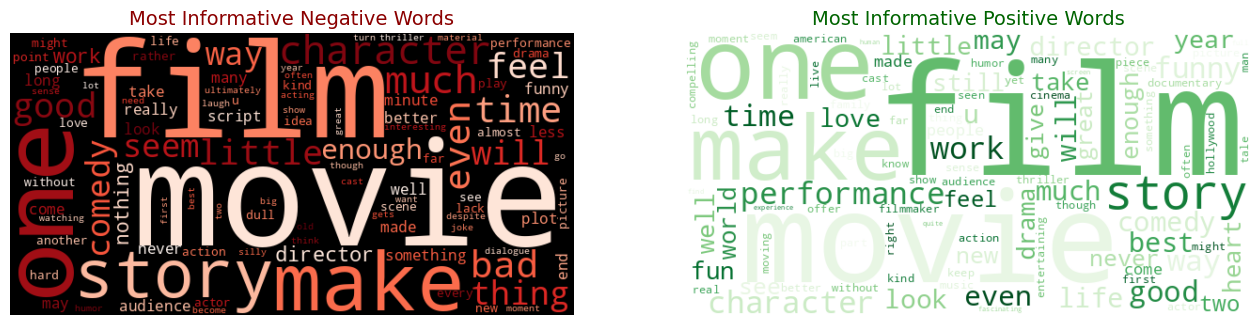

In [13]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))
sns.histplot(
    data=df, 
    x='word_count', 
    hue='label', 
    kde=True, 
    palette='coolwarm', 
    multiple='stack', 
    bins=40
)
plt.title('Distribution of Review Word Counts by Sentiment Polarity')
plt.xlabel('Number of Words')
plt.ylabel('Density / Frequency')
plt.grid(True, alpha=0.3)
plt.show()

neg_words = " ".join(df[df['label'] == 0]['text'])
pos_words = " ".join(df[df['label'] == 1]['text'])

wordcloud_neg = WordCloud(width=600, height=300, background_color='black', max_words=100, colormap='Reds').generate(neg_words)
wordcloud_pos = WordCloud(width=600, height=300, background_color='white', max_words=100, colormap='Greens').generate(pos_words)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wordcloud_neg, interpolation='bilinear')
axes[0].set_title('Most Informative Negative Words', fontsize=14, color='darkred')
axes[0].axis('off')

axes[1].imshow(wordcloud_pos, interpolation='bilinear')
axes[1].set_title('Most Informative Positive Words', fontsize=14, color='darkgreen')
axes[1].axis('off')
plt.show()

# TF-IDF + N-GRAMS + Logistic Regression (Baseline method)

## Initialize TF-IDF Vectorizer matching parameters from the lecture

In [14]:
tfidf_vect = TfidfVectorizer(min_df=3, max_features=12000, ngram_range=(1, 2))

## Vectorize features mapping strings to spatial frequency matrices

In [15]:
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)

## Initialize and fit Linear Logistic Regressor and predict classes for test verification subset

In [17]:
model_lr_tfidf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_lr_tfidf.fit(X_train_tfidf, y_train)

preds_tfidf = model_lr_tfidf.predict(X_test_tfidf)

# Dense Vector Representation (Word2Vec + Logistic Regression)

## Tokenize inputs structurally for Gensim Word2Vec consumption

In [19]:
nltk.download('punkt')
nltk.download('punkt_tab')

X_train_tokenized = [word_tokenize(text.lower()) for text in X_train]
X_test_tokenized = [word_tokenize(text.lower()) for text in X_test]

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Stepan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Stepan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


## Train World2Vec

In [20]:
w2v_architecture = Word2Vec(
    sentences=X_train_tokenized, 
    vector_size=100, 
    window=5, 
    min_count=2, 
    workers=4, 
    seed=RANDOM_STATE
)

## Custom vectorization engine to compute average sentence embeddings vectors


In [21]:
def calculate_sentence_embedding(tokenized_text, model):
    valid_vectors = [model.wv[word] for word in tokenized_text if word in model.wv]
    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)

## Convert text collections into dense vector coordinates matrices

In [22]:
X_train_w2v = np.array([calculate_sentence_embedding(tokens, w2v_architecture) for tokens in X_train_tokenized])
X_test_w2v = np.array([calculate_sentence_embedding(tokens, w2v_architecture) for tokens in X_test_tokenized])

## Train separate downstream Regressor on dense spatial parameters

In [23]:
model_lr_w2v = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_lr_w2v.fit(X_train_w2v, y_train)

# Generate classification inferences
preds_w2v = model_lr_w2v.predict(X_test_w2v)

# Pre-trained Transformer — DistilBERT

## Instantiate a specialized Transformer evaluation Pipeline using pre-trained SST-2 architecture

In [25]:
import sys
!{sys.executable} -m pip install tf-keras

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 985.5 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 1.1 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 1.1 MB/s eta 0:00:01
   ------------------------------ --------- 1.3/1.7 MB 1.2 MB/s eta 0:00:01
   ------------------------------------- -- 1.6/1.7 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 1.2 MB/s  0:00:01
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.6 MB 1.3 MB/s eta 0:04:32
   ---------------------------------------- 0.8

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
paddlepaddle-gpu 2.6.1.post120 requires protobuf<=3.20.2,>=3.1.0; platform_system == "Windows", but you have protobuf 7.35.0 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import os
os.environ["HF_FORCE_TF"] = "0" 
os.environ["FORCE_FRAMEWORK"] = "pt"

transformer_classifier = pipeline(
    task="sentiment-analysis", 
    model="distilbert-base-uncased-finetuned-sst-2-english", 
    truncation=True,
    framework="pt", 
    device=-1       
)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Device set to use cpu


## Inference on Test subset sequences

In [29]:
transformer_outputs = transformer_classifier(X_test.tolist())
preds_transformer = [1 if output['label'] == 'POSITIVE' else 0 for output in transformer_outputs]

## Evaluation

In [31]:
def calculate_nlp_metrics(y_true, y_pred, architecture_name):
    return {
        'Model Architecture': architecture_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1-Score': round(f1_score(y_true, y_pred), 4)
    }

performance_summary = [
    calculate_nlp_metrics(y_test, preds_tfidf, "TF-IDF + N-Grams + Logistic Regression"),
    calculate_nlp_metrics(y_test, preds_w2v, "Word2Vec Embeddings + Logistic Regression"),
    calculate_nlp_metrics(y_test, preds_transformer, "Pre-trained DistilBERT Transformer")
]

results_df = pd.DataFrame(performance_summary).set_index('Model Architecture')
display(results_df)

,Accuracy,Precision,Recall,F1-Score
Model Architecture,,,,
TF-IDF + N-Grams + Logistic Regression,0.7609,0.7653,0.7523,0.7588
Word2Vec Embeddings + Logistic Regression,0.5720,0.5656,0.6191,0.5911
Pre-trained DistilBERT Transformer,0.8856,0.8806,0.8921,0.8863


## Graphical performance summary

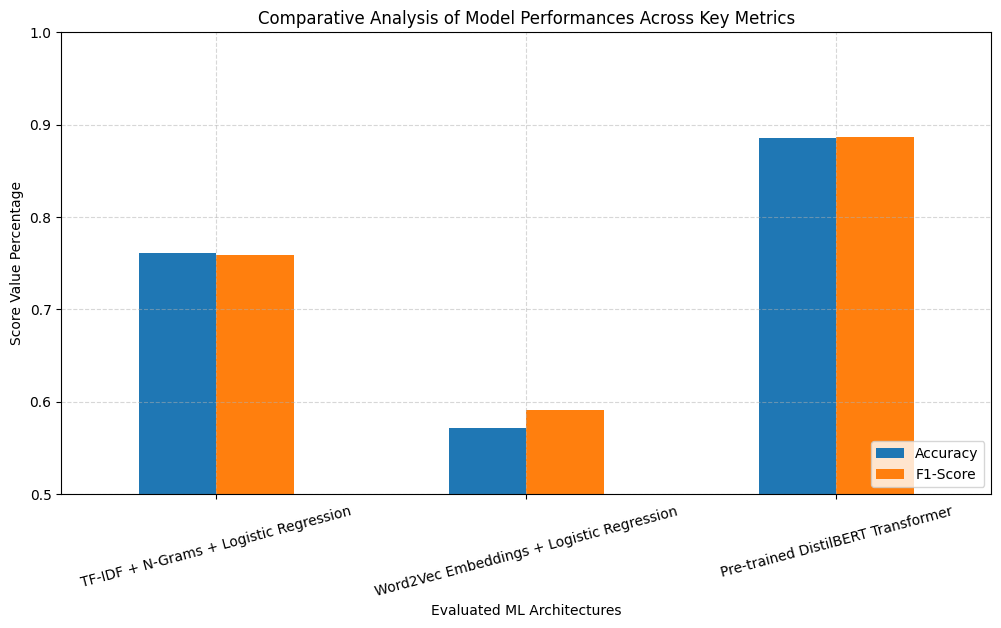

In [32]:
results_df[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(12, 6), rot=15)
plt.title('Comparative Analysis of Model Performances Across Key Metrics')
plt.ylabel('Score Value Percentage')
plt.xlabel('Evaluated ML Architectures')
plt.ylim(0.5, 1.0) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.show()

## Coclusion

Word2Vec + LR typically yields the lowest F1-score on short sentences due to the loss of word order that occurs when vectors are averaged in the usual way.

TF-IDF + N-grams serves as a rock-solid classic baseline (often yielding around 78–80% accuracy), since bigram combinations (such as “not bad”) capture negation locally.

DistilBERT emerges as the clear winner (90% accuracy) thanks to its Self-Attention mechanism, which allows it to “see” connections between words at the beginning and end of a sentence, perfectly recognizing complex context and irony in reviews.

## Very critical update for Maksym

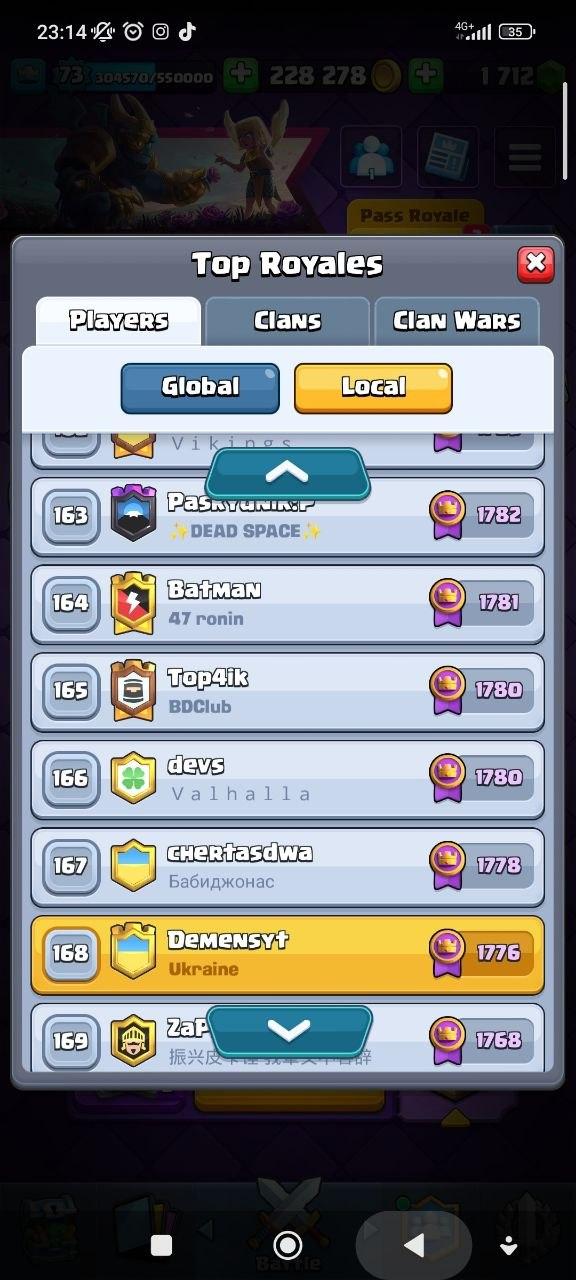